In [ ]:
# 1. INSTALL CONVERSION LIBRARY
!pip install mygene -q
import mygene
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 2. MOUNT DRIVE
drive.mount('/content/drive')

# 3. DEFINE PATHS
# Change 'Test_Matrix_CIBER.tsv' if your filename is different
input_folder = '/content/drive/My Drive/CIBERSORT_ANALYSIS'
input_filename = 'merged_expression_genes_x_samples.tsv'
input_path = os.path.join(input_folder, input_filename)

print(f"Loading file: {input_path}...")

# 4. LOAD DATA
# Load the matrix. We use on_bad_lines='skip' to ignore any malformed rows.
try:
    df = pd.read_csv(input_path, sep='\t', index_col=0, on_bad_lines='skip')
except:
    # Fallback for some Excel-saved TSVs
    df = pd.read_csv(input_path, sep='\t', index_col=None)
    df.set_index(df.columns[0], inplace=True)

print(f"Original Shape: {df.shape}")

# 5. PREPARE ENSEMBL IDs
# Strip version numbers (e.g., ENSG000001.5 -> ENSG000001)
df.index = df.index.astype(str).str.split('.').str[0]

# 6. MAP TO SYMBOLS (Using MyGene.info)
print("Querying MyGene database (converting Ensembl -> Symbol)...")
mg = mygene.MyGeneInfo()
ensembl_ids = df.index.tolist()

# Query batch
results = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=True)

# Create Mapper Dictionary {ENSG... : SYMBOL}
# Filter out failures first
results = results[~results['symbol'].isna()]
mapper = results['symbol'].to_dict()

# Apply Mapping
df.index = df.index.map(mapper)

# Drop rows that couldn't be mapped (NaN index)
df = df[df.index.notnull()]
print(f"Genes successfully mapped to Symbols: {df.shape[0]}")

# 7. CLEANING & FORMATTING
# A. Uppercase (Required for LM22)
df.index = df.index.str.upper()

# B. Handle Duplicates (Average rows with same Gene Symbol)
if df.index.duplicated().any():
    print(f"Merging {df.index.duplicated().sum()} duplicate gene symbols (by averaging)...")
    df = df.groupby(df.index).mean()

# C. Force Numeric & Fill NAs
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

# D. Set Index Name
df.index.name = 'GeneSymbol'

# 8. SAVE AS SINGLE FILE
output_filename = 'CIBERSORTx_Input_Mapped_FULL.txt'
output_path = os.path.join(input_folder, output_filename)

print("Saving full matrix...")
# Use lineterminator='\n' for Linux/CIBERSORTx compatibility
df.to_csv(output_path, sep='\t', lineterminator='\n')

print("\nSUCCESS! ------------------------------------------------")
print(f"Full Mapped Matrix saved to: {output_path}")
print("---------------------------------------------------------")
print("ACTION: Upload 'CIBERSORTx_Input_Mapped_FULL.txt' as your Mixture File.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading file: /content/drive/My Drive/CIBERSORT_ANALYSIS/merged_expression_genes_x_samples.tsv...


INFO:biothings.client:querying 1-1000 ...


Original Shape: (60660, 709)
Querying MyGene database (converting Ensembl -> Symbol)...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 21001-22000 ...
INFO:biothings.client:querying

Genes successfully mapped to Symbols: 45083
Merging 1085 duplicate gene symbols (by averaging)...
Saving full matrix...

SUCCESS! ------------------------------------------------
Full Mapped Matrix saved to: /content/drive/My Drive/CIBERSORT_ANALYSIS/CIBERSORTx_Input_Mapped_FULL.txt
---------------------------------------------------------
ACTION: Upload 'CIBERSORTx_Input_Mapped_FULL.txt' as your Mixture File.


In [ ]:
import pandas as pd
import os
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')

# 2. PATHS
# Use the "FULL" mapped file you created earlier
input_folder = '/content/drive/My Drive/CIBERSORT_ANALYSIS'
input_filename = 'CIBERSORTx_Input_Mapped_FULL.txt'
input_path = os.path.join(input_folder, input_filename)

print(f"Reading file: {input_path}...")
df = pd.read_csv(input_path, sep='\t', index_col=0)

# 3. AGGRESSIVE SIZE REDUCTION
# Step A: Round to 3 decimal places.
# Immune algorithms do not need 10 decimal places. This saves ~40% space.
print("Rounding values to 3 decimal places to save space...")
df = df.round(3)

# Step B: Split into 10 chunks (approx 70 patients each)
n_splits = 10
chunk_size = int(df.shape[1] / n_splits) + 1

print(f"Splitting into {n_splits} mini-files...")

for i in range(n_splits):
    start_col = i * chunk_size
    end_col = min((i + 1) * chunk_size, df.shape[1])

    if start_col >= df.shape[1]:
        break

    df_subset = df.iloc[:, start_col:end_col]

    output_name = f'TIMER3_Mini_Part_{i+1}.txt'
    output_path = os.path.join(input_folder, output_name)

    # Save with standard line terminators
    df_subset.to_csv(output_path, sep='\t', lineterminator='\n')

    # Check file size in MB
    size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"Saved Part {i+1}: {size_mb:.2f} MB")

print("\n------------------------------------------------")
print("If the files are under 50MB, they should upload.")
print("Try uploading 'TIMER3_Mini_Part_1.txt' now.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading file: /content/drive/My Drive/CIBERSORT_ANALYSIS/CIBERSORTx_Input_Mapped_FULL.txt...
Rounding values to 3 decimal places to save space...
Splitting into 10 mini-files...
Saved Part 1: 15.76 MB
Saved Part 2: 15.82 MB
Saved Part 3: 15.72 MB
Saved Part 4: 15.70 MB
Saved Part 5: 15.68 MB
Saved Part 6: 15.74 MB
Saved Part 7: 15.68 MB
Saved Part 8: 15.68 MB
Saved Part 9: 15.71 MB
Saved Part 10: 15.51 MB

------------------------------------------------
If the files are under 50MB, they should upload.
Try uploading 'TIMER3_Mini_Part_1.txt' now.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Data...

Standardizing IDs and removing duplicates...
Cleaned Data Counts:
 - Immune Patients: 704
 - Clinical Patients: 704
 - Expression Patients: 704

Final Analysis Cohort: 413 IDH-Mutant Patients
Screening 22 cell types...


/tmp/ipython-input-2609195947.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R', y='Cell_Type', data=res_df, palette=colors.tolist())


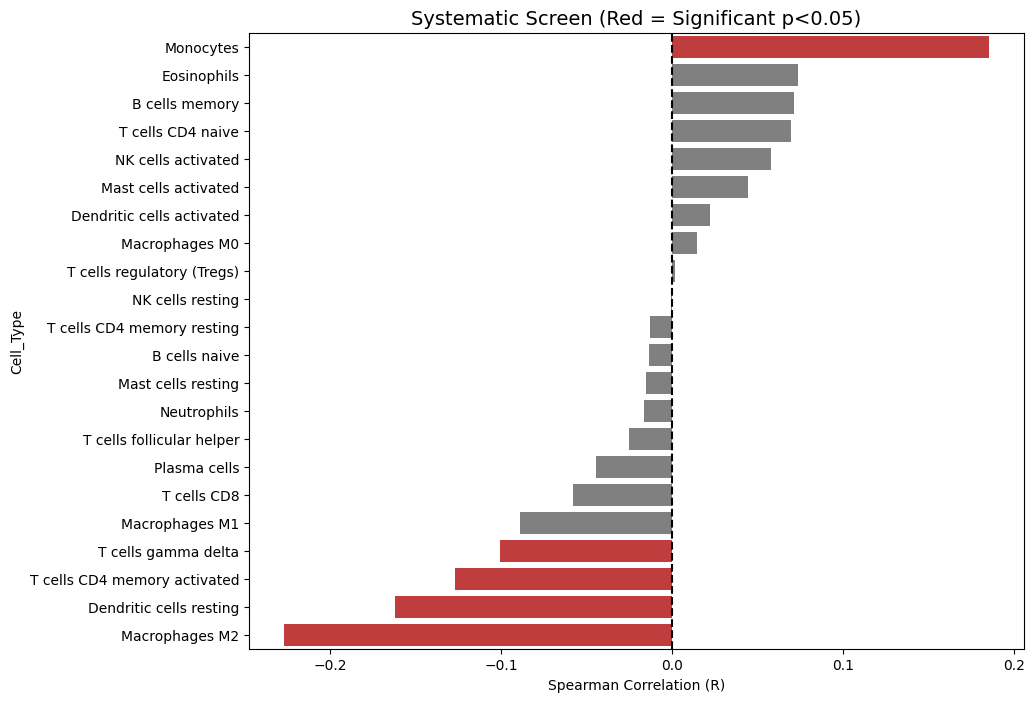


SUCCESS! Plot saved to: /content/drive/My Drive/Immune_Analysis/Final_Screening_Heatmap_Fixed.png

Top Significant Associations:
                       Cell_Type         R   P_Value
12                     Monocytes  0.185081  0.000155
9            T cells gamma delta -0.100746  0.040718
6   T cells CD4 memory activated -0.127277  0.009618
16       Dendritic cells resting -0.161972  0.000955
15                Macrophages M2 -0.227006  0.000003


In [ ]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')

# ==========================================
# USER PATHS
# ==========================================
base_folder = '/content/drive/My Drive/Immune_Analysis'
results_folder = os.path.join(base_folder, 'CIBERSORTx_OUTPUT')
expression_file = os.path.join(base_folder, 'CIBERSORTx_Input_Mapped_FULL.txt')
signature_list_file = os.path.join(base_folder, '1C_Genes_List.txt')
clinical_file = os.path.join(base_folder, 'IDH1_status_table.csv')

# ==========================================
# STEP 1: LOAD DATA
# ==========================================
print("Loading Data...")

# A. Load Gene List
try:
    with open(signature_list_file, 'r') as f:
        my_signature = [line.strip().upper() for line in f if line.strip()]
except: my_signature = []

# B. Load & Merge CIBERSORTx Results
all_files = glob.glob(os.path.join(results_folder, "*.txt"))
if not all_files: all_files = glob.glob(os.path.join(results_folder, "*.csv"))

dfs = []
for filename in all_files:
    try:
        df = pd.read_csv(filename, sep='\t', index_col=0)
        if len(df.columns) < 2: df = pd.read_csv(filename, sep=',', index_col=0)
        dfs.append(df)
    except: pass

if not dfs: raise ValueError("No CIBERSORTx result files found!")
immune_df = pd.concat(dfs, axis=0)

# C. Load Expression
expr_df = pd.read_csv(expression_file, sep='\t', index_col=0)

# D. Load Clinical
clin_df = pd.read_csv(clinical_file, index_col=0)
status_col = clin_df.columns[0]

# ==========================================
# STEP 2: TRIM IDs & REMOVE DUPLICATES (THE FIX)
# ==========================================
print("\nStandardizing IDs and removing duplicates...")

# 1. Trim to 15 chars (TCGA Standard)
immune_df.index = immune_df.index.str[:15]
expr_df.columns = expr_df.columns.str[:15]
clin_df.index = clin_df.index.str[:15]

# 2. FORCE UNIQUE INDICES (This fixes your error)
# If a patient appears twice, we keep the first occurrence.
immune_df = immune_df[~immune_df.index.duplicated(keep='first')]
clin_df = clin_df[~clin_df.index.duplicated(keep='first')]

# For expression, since patients are columns, we transpose first, deduplicate, then use.
expr_df_T = expr_df.T
expr_df_T = expr_df_T[~expr_df_T.index.duplicated(keep='first')]

print(f"Cleaned Data Counts:")
print(f" - Immune Patients: {len(immune_df)}")
print(f" - Clinical Patients: {len(clin_df)}")
print(f" - Expression Patients: {len(expr_df_T)}")

# ==========================================
# STEP 3: CALCULATE SCORE & MERGE
# ==========================================
# Recalculate score on the cleaned dataframe
valid_genes = [g for g in my_signature if g in expr_df_T.columns]
sig_score = expr_df_T[valid_genes].mean(axis=1)
sig_score.name = 'Signature_Score'

# MERGE (Safe now because indices are unique)
full_data = pd.concat([sig_score, immune_df, clin_df], axis=1, join='inner')

# ==========================================
# STEP 4: FILTER MUTANTS & RUN HEATMAP
# ==========================================
# Filter for "MT"
mask = full_data[status_col].astype(str).str.strip() == 'MT'
mutant_df = full_data[mask]
print(f"\nFinal Analysis Cohort: {len(mutant_df)} IDH-Mutant Patients")

if len(mutant_df) == 0:
    raise ValueError("No Mutant patients found! Check if your clinical file uses 'MT'.")

# SYSTEMATIC SCREEN
immune_cols = [c for c in immune_df.columns if c not in ['P-value', 'Correlation', 'RMSE', 'Signature_Score']]
results = []

print(f"Screening {len(immune_cols)} cell types...")

for cell in immune_cols:
    if cell in mutant_df.columns:
        corr, p = spearmanr(mutant_df['Signature_Score'], mutant_df[cell])
        results.append({'Cell_Type': cell, 'R': corr, 'P_Value': p})

res_df = pd.DataFrame(results).sort_values(by='R', ascending=False)

# PLOT HEATMAP
plt.figure(figsize=(10, 8))
colors = res_df['P_Value'].apply(lambda x: '#D62728' if x < 0.05 else 'grey')
sns.barplot(x='R', y='Cell_Type', data=res_df, palette=colors.tolist())
plt.title('Systematic Screen (Red = Significant p<0.05)', fontsize=14)
plt.xlabel('Spearman Correlation (R)')
plt.axvline(0, color='black', linestyle='--')

save_path = os.path.join(base_folder, 'Final_Screening_Heatmap_Fixed.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(f"\nSUCCESS! Plot saved to: {save_path}")
print("\nTop Significant Associations:")
print(res_df[res_df['P_Value'] < 0.05][['Cell_Type', 'R', 'P_Value']])

In [ ]:
# ==========================================
# STEP 5: SAVE SORTED STATISTICAL RESULTS
# ==========================================
print("\nSaving statistical results to CSV...")

# 1. Sort by Strength (Absolute R value) so strongest hits are at the top
# We create a temporary column for sorting magnitude, then drop it
res_df['Abs_R'] = res_df['R'].abs()
sorted_df = res_df.sort_values(by='Abs_R', ascending=False).drop(columns=['Abs_R'])

# 2. Rename columns for publication quality
sorted_df = sorted_df.rename(columns={
    'Cell_Type': 'Immune Cell Type',
    'R': 'Spearman Coefficient (R)',
    'P_Value': 'P-Value'
})

# 3. Save to CSV
csv_path = os.path.join(base_folder, 'Final_Immune_Correlations_Sorted.csv')
sorted_df.to_csv(csv_path, index=False)

print(f"SUCCESS! Statistics saved to: {csv_path}")
print("Top 5 Strongest Hits:")
print(sorted_df.head(5))


Saving statistical results to CSV...
SUCCESS! Statistics saved to: /content/drive/My Drive/Immune_Analysis/Final_Immune_Correlations_Sorted.csv
Top 5 Strongest Hits:
                Immune Cell Type  Spearman Coefficient (R)   P-Value
15                Macrophages M2                 -0.227006  0.000003
12                     Monocytes                  0.185081  0.000155
16       Dendritic cells resting                 -0.161972  0.000955
6   T cells CD4 memory activated                 -0.127277  0.009618
9            T cells gamma delta                 -0.100746  0.040718


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Data...
Cleaning duplicates...
Analyzing 413 Mutant Patients.

Calculating correlations for 64 genes vs Top 5 cells...


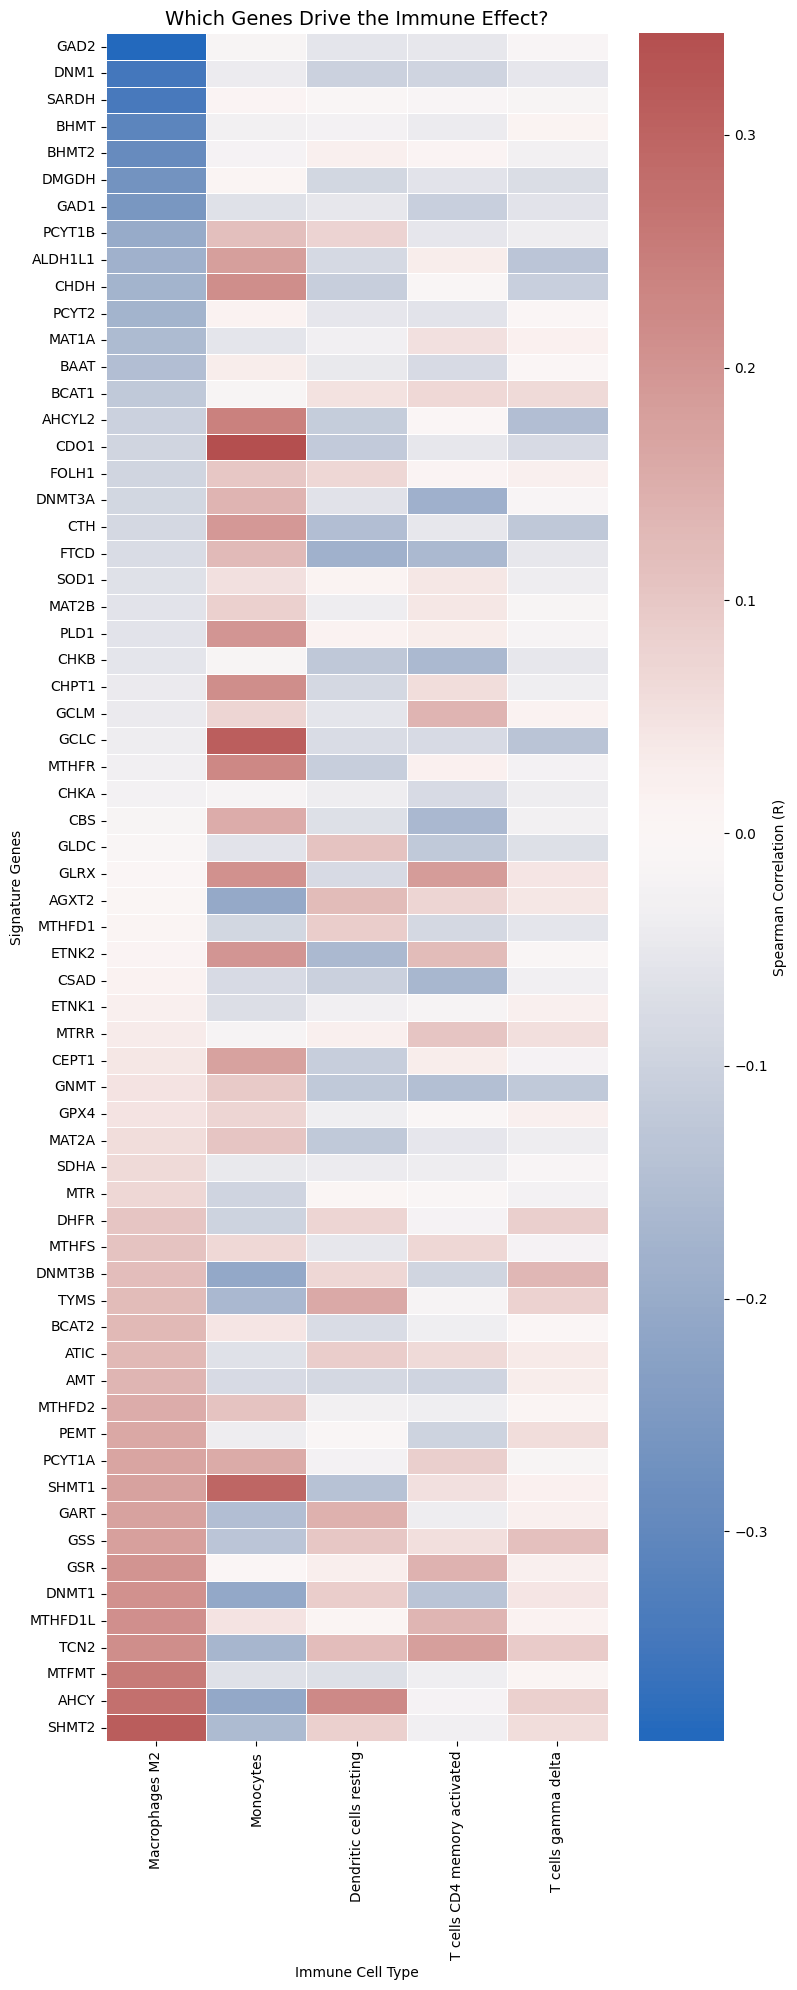

Success! Heatmap saved to: /content/drive/My Drive/Immune_Analysis/Detailed_Gene_Deconvolution.png


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os
import glob
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')
base_folder = '/content/drive/My Drive/Immune_Analysis'

# ==========================================
# USER SETTINGS
# ==========================================
# Your Top 5 Immune Cells (Copy EXACTLY from your CSV)
top_immune_cells = [
    'Macrophages M2',
    'Monocytes',
    'Dendritic cells resting',
    'T cells CD4 memory activated',
    'T cells gamma delta'
]

# Paths
results_folder = os.path.join(base_folder, 'CIBERSORTx_OUTPUT')
expression_file = os.path.join(base_folder, 'CIBERSORTx_Input_Mapped_FULL.txt')
signature_list_file = os.path.join(base_folder, '1C_Genes_List.txt')
clinical_file = os.path.join(base_folder, 'IDH1_status_table.csv')

# ==========================================
# STEP 1: LOAD & CLEAN DATA
# ==========================================
print("Loading Data...")

# A. Load Gene List
with open(signature_list_file, 'r') as f:
    my_signature = [line.strip().upper() for line in f if line.strip()]

# B. Load Immune Results
all_files = glob.glob(os.path.join(results_folder, "*.txt"))
if not all_files: all_files = glob.glob(os.path.join(results_folder, "*.csv"))

dfs = []
for f in all_files:
    try:
        d = pd.read_csv(f, sep='\t', index_col=0)
        if len(d.columns) < 2: d = pd.read_csv(f, sep=',', index_col=0)
        dfs.append(d)
    except: pass
immune_df = pd.concat(dfs, axis=0)

# C. Load Expression & Clinical
expr_df = pd.read_csv(expression_file, sep='\t', index_col=0)
clin_df = pd.read_csv(clinical_file, index_col=0)
status_col = clin_df.columns[0]

# ==========================================
# STEP 2: AGGRESSIVE DE-DUPLICATION (THE FIX)
# ==========================================
print("Cleaning duplicates...")

# 1. Trim IDs
immune_df.index = immune_df.index.str[:15]
expr_df.columns = expr_df.columns.str[:15]
clin_df.index = clin_df.index.str[:15]

# 2. Remove Duplicates (Keep first occurrence)
immune_df = immune_df[~immune_df.index.duplicated(keep='first')]
clin_df = clin_df[~clin_df.index.duplicated(keep='first')]

# 3. Transpose Expression & Remove Duplicates
expr_df_T = expr_df.T
expr_df_T = expr_df_T[~expr_df_T.index.duplicated(keep='first')]

# ==========================================
# STEP 3: MERGE & FILTER MUTANTS
# ==========================================
# Filter expression for just the signature genes
valid_genes = [g for g in my_signature if g in expr_df_T.columns]
subset_expr = expr_df_T[valid_genes]

# Merge
full_data = pd.concat([subset_expr, immune_df, clin_df], axis=1, join='inner')

# Filter for "MT"
mask = full_data[status_col].astype(str).str.strip() == 'MT'
mutant_df = full_data[mask]
print(f"Analyzing {len(mutant_df)} Mutant Patients.")

# ==========================================
# STEP 4: GENERATE TARGETED HEATMAP
# ==========================================
print("\nCalculating correlations for 64 genes vs Top 5 cells...")

results = []

for gene in valid_genes:
    row_data = {'Gene': gene}
    for cell in top_immune_cells:
        # Check if cell exists in data
        if cell in mutant_df.columns:
            corr, p = spearmanr(mutant_df[gene], mutant_df[cell])
            row_data[cell] = corr
        else:
            row_data[cell] = 0 # Fill 0 if cell missing
    results.append(row_data)

# Create Matrix for Heatmap
heatmap_data = pd.DataFrame(results).set_index('Gene')

# Sort by the most important cell (First one in your list)
primary_cell = top_immune_cells[0]
if primary_cell in heatmap_data.columns:
    heatmap_data = heatmap_data.sort_values(by=primary_cell, ascending=True)

# PLOT
plt.figure(figsize=(8, 20)) # Tall figure

# 'vlag' colormap: Blue = Negative, White = Zero, Red = Positive
sns.heatmap(heatmap_data, cmap='vlag', center=0, annot=False,
            linewidths=0.5, cbar_kws={'label': 'Spearman Correlation (R)'})

plt.title('Which Genes Drive the Immune Effect?', fontsize=14)
plt.xlabel('Immune Cell Type')
plt.ylabel('Signature Genes')
plt.tight_layout()

save_path = os.path.join(base_folder, 'Detailed_Gene_Deconvolution.png')
plt.savefig(save_path)
plt.show()

print(f"Success! Heatmap saved to: {save_path}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os
import glob
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')
base_folder = '/content/drive/My Drive/Immune_Analysis'

# ==========================================
# USER SETTINGS: YOUR TOP 5 CELLS
# ==========================================
# (These must match the column names in your CIBERSORTx file exactly)
top_immune_cells = [
    'Macrophages M2',
    'Monocytes',
    'Dendritic cells resting',
    'T cells CD4 memory activated',
    'T cells gamma delta'
]

# Paths
results_folder = os.path.join(base_folder, 'CIBERSORTx_OUTPUT')
expression_file = os.path.join(base_folder, 'CIBERSORTx_Input_Mapped_FULL.txt')
signature_list_file = os.path.join(base_folder, '1C_Genes_List.txt')
clinical_file = os.path.join(base_folder, 'IDH1_status_table.csv')

# Output Folder
output_folder = os.path.join(base_folder, 'Top3_Driver_Plots')
os.makedirs(output_folder, exist_ok=True)

# ==========================================
# STEP 1: LOAD & CLEAN DATA (With Duplicate Fix)
# ==========================================
print("Loading and cleaning data...")

# Load Gene List
try:
    with open(signature_list_file, 'r') as f:
        my_signature = [line.strip().upper() for line in f if line.strip()]
except: my_signature = []

# Load Immune Results
all_files = glob.glob(os.path.join(results_folder, "*.txt"))
if not all_files: all_files = glob.glob(os.path.join(results_folder, "*.csv"))
dfs = []
for f in all_files:
    try:
        d = pd.read_csv(f, sep='\t', index_col=0)
        if len(d.columns)<2: d = pd.read_csv(f, sep=',', index_col=0)
        dfs.append(d)
    except: pass
immune_df = pd.concat(dfs, axis=0)

# Load Expr & Clinical
expr_df = pd.read_csv(expression_file, sep='\t', index_col=0)
clin_df = pd.read_csv(clinical_file, index_col=0)
status_col = clin_df.columns[0]

# --- AGGRESSIVE CLEANING ---
immune_df.index = immune_df.index.str[:15]
expr_df.columns = expr_df.columns.str[:15]
clin_df.index = clin_df.index.str[:15]

immune_df = immune_df[~immune_df.index.duplicated(keep='first')]
clin_df = clin_df[~clin_df.index.duplicated(keep='first')]
expr_df_T = expr_df.T
expr_df_T = expr_df_T[~expr_df_T.index.duplicated(keep='first')]

# MERGE
valid_genes = [g for g in my_signature if g in expr_df_T.columns]
subset_expr = expr_df_T[valid_genes]
full_data = pd.concat([subset_expr, immune_df, clin_df], axis=1, join='inner')

# FILTER MUTANTS
mask = full_data[status_col].astype(str).str.strip() == 'MT'
mutant_df = full_data[mask]
print(f"Analyzing {len(mutant_df)} Mutant Patients.")

# ==========================================
# STEP 2: FIND & PLOT TOP 3 GENES
# ==========================================
print("\nFinding Top 3 Driver Genes for each cell type...")

for cell in top_immune_cells:
    if cell not in mutant_df.columns:
        print(f"Skipping {cell} (Not found in data)")
        continue

    print(f"\nAnalyzing Drivers for: {cell}")

    # 1. Calculate correlations for ALL signature genes against this cell
    gene_stats = []
    for gene in valid_genes:
        r, p = spearmanr(mutant_df[gene], mutant_df[cell])
        gene_stats.append({
            'Gene': gene,
            'R': r,
            'Abs_R': abs(r), # We sort by magnitude (Absolute value)
            'P': p
        })

    # 2. Sort and take Top 3
    stats_df = pd.DataFrame(gene_stats)
    top_3 = stats_df.sort_values(by='Abs_R', ascending=False).head(3)

    # 3. Loop through the Top 3 and Plot
    rank = 1
    for index, row in top_3.iterrows():
        gene = row['Gene']
        r_val = row['R']
        p_val = row['P']

        print(f"  #{rank}: {gene} (R={r_val:.3f})")

        plt.figure(figsize=(7, 6))

        # Color: Red for Positive, Blue for Negative
        col = '#D62728' if r_val > 0 else '#1F77B4'

        sns.regplot(x=gene, y=cell, data=mutant_df, color=col, scatter_kws={'alpha':0.6})

        plt.title(f'{cell} Driver #{rank}\nGene: {gene} (R={r_val:.3f}, p={p_val:.4e})')
        plt.xlabel(f'{gene} Expression')
        plt.ylabel(f'{cell} Abundance')
        plt.grid(True, linestyle='--', alpha=0.3)

        # Clean filename
        safe_cell = cell.replace(' ', '_').replace('/', '-')
        fname = f"{safe_cell}_Rank{rank}_{gene}.png"

        plt.savefig(os.path.join(output_folder, fname))
        plt.close()

        rank += 1

print(f"\nDONE! Generated 15 plots (5 cells * 3 genes).")
print(f"Check the folder: {output_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading and cleaning data...
Analyzing 413 Mutant Patients.

Finding Top 3 Driver Genes for each cell type...

Analyzing Drivers for: Macrophages M2
  #1: GAD2 (R=-0.390)
  #2: DNM1 (R=-0.349)
  #3: SARDH (R=-0.341)

Analyzing Drivers for: Monocytes
  #1: CDO1 (R=0.344)
  #2: GCLC (R=0.310)
  #3: SHMT1 (R=0.296)

Analyzing Drivers for: Dendritic cells resting
  #1: AHCY (R=0.220)
  #2: FTCD (R=-0.186)
  #3: ETNK2 (R=-0.163)

Analyzing Drivers for: T cells CD4 memory activated
  #1: GLRX (R=0.188)
  #2: DNMT3A (R=-0.187)
  #3: TCN2 (R=0.183)

Analyzing Drivers for: T cells gamma delta
  #1: AHCYL2 (R=-0.152)
  #2: GCLC (R=-0.135)
  #3: ALDH1L1 (R=-0.134)

DONE! Generated 15 plots (5 cells * 3 genes).
Check the folder: /content/drive/My Drive/Immune_Analysis/Top3_Driver_Plots


**To do all analysis repeat for WT patients**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os
import glob
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')
base_folder = '/content/drive/My Drive/Immune_Analysis'

# ==========================================
# OUTPUT FOLDER (NEW)
# ==========================================
output_folder = os.path.join(base_folder, 'results_wt_patients_only')
os.makedirs(output_folder, exist_ok=True)
print(f"All results will be saved to: {output_folder}")

# Paths
results_folder = os.path.join(base_folder, 'CIBERSORTx_OUTPUT')
expression_file = os.path.join(base_folder, 'CIBERSORTx_Input_Mapped_FULL.txt')
signature_list_file = os.path.join(base_folder, '1C_Genes_List.txt')
clinical_file = os.path.join(base_folder, 'IDH1_status_table.csv')

# ==========================================
# STEP 1: LOAD & CLEAN DATA
# ==========================================
print("Loading Data...")

# A. Load Gene List
with open(signature_list_file, 'r') as f:
    my_signature = [line.strip().upper() for line in f if line.strip()]

# B. Load Immune Results
all_files = glob.glob(os.path.join(results_folder, "*.txt"))
if not all_files: all_files = glob.glob(os.path.join(results_folder, "*.csv"))
dfs = []
for f in all_files:
    try:
        d = pd.read_csv(f, sep='\t', index_col=0)
        if len(d.columns) < 2: d = pd.read_csv(f, sep=',', index_col=0)
        dfs.append(d)
    except: pass
immune_df = pd.concat(dfs, axis=0)

# C. Load Expr & Clinical
expr_df = pd.read_csv(expression_file, sep='\t', index_col=0)
clin_df = pd.read_csv(clinical_file, index_col=0)
status_col = clin_df.columns[0]

# D. AGGRESSIVE CLEANING (Duplicate Fix)
print("Cleaning duplicates and standardizing IDs...")
immune_df.index = immune_df.index.str[:15]
expr_df.columns = expr_df.columns.str[:15]
clin_df.index = clin_df.index.str[:15]

immune_df = immune_df[~immune_df.index.duplicated(keep='first')]
clin_df = clin_df[~clin_df.index.duplicated(keep='first')]
expr_df_T = expr_df.T
expr_df_T = expr_df_T[~expr_df_T.index.duplicated(keep='first')]

# E. MERGE
valid_genes = [g for g in my_signature if g in expr_df_T.columns]
subset_expr = expr_df_T[valid_genes]
# Calculate Combined Score
subset_expr['Signature_Score'] = subset_expr.mean(axis=1)

full_data = pd.concat([subset_expr, immune_df, clin_df], axis=1, join='inner')

# ==========================================
# STEP 2: FILTER FOR "WT" (WILDTYPE)
# ==========================================
# We filter for 'WT' in the status column
mask = full_data[status_col].astype(str).str.strip() == 'WT'
wt_df = full_data[mask]

print(f"\nAnalyzing {len(wt_df)} WT Patients.")

if len(wt_df) < 5:
    raise ValueError("Too few WT patients found! Check your IDH1_status_table.csv to ensure it uses 'WT'.")

# ==========================================
# STEP 3: SYSTEMATIC SCREEN (HEATMAP)
# ==========================================
print("\n[A] Running Systematic Screen (Combined Score vs 22 Cells)...")

immune_cols = [c for c in immune_df.columns if c not in ['P-value', 'Correlation', 'RMSE', 'Signature_Score']]
results = []

for cell in immune_cols:
    if cell in wt_df.columns:
        corr, p = spearmanr(wt_df['Signature_Score'], wt_df[cell])
        results.append({'Cell_Type': cell, 'R': corr, 'P_Value': p, 'Abs_R': abs(corr)})

res_df = pd.DataFrame(results).sort_values(by='Abs_R', ascending=False)

# Save Plot
plt.figure(figsize=(10, 8))
colors = res_df['P_Value'].apply(lambda x: '#D62728' if x < 0.05 else 'grey')
sns.barplot(x='R', y='Cell_Type', data=res_df, palette=colors.tolist())
plt.title('WT Control Group: Systematic Screen', fontsize=14)
plt.xlabel('Spearman Correlation (R)')
plt.axvline(0, color='black', linestyle='--')
plt.savefig(os.path.join(output_folder, 'WT_Screening_Heatmap.png'), bbox_inches='tight')
plt.close()

# ==========================================
# STEP 4: SAVE STATISTICS (CSV)
# ==========================================
print("\n[B] Saving WT Statistics to CSV...")
csv_save = res_df.drop(columns=['Abs_R'])
csv_save.to_csv(os.path.join(output_folder, 'WT_Correlations_Sorted.csv'), index=False)

# Identify Top 5 WT Hits
top_5_cells = res_df.head(5)['Cell_Type'].tolist()
print(f"Top 5 correlations in WT Group: {top_5_cells}")

# ==========================================
# STEP 5: INDIVIDUAL GENE HEATMAP (Deconvolution)
# ==========================================
print("\n[C] Generating Gene Deconvolution Heatmap for Top 5 WT Cells...")

deconv_results = []
for gene in valid_genes:
    row_data = {'Gene': gene}
    for cell in top_5_cells:
        corr, p = spearmanr(wt_df[gene], wt_df[cell])
        row_data[cell] = corr
    deconv_results.append(row_data)

heatmap_data = pd.DataFrame(deconv_results).set_index('Gene')
heatmap_data = heatmap_data.sort_values(by=top_5_cells[0], ascending=True)

plt.figure(figsize=(8, 20))
sns.heatmap(heatmap_data, cmap='vlag', center=0, annot=False,
            linewidths=0.5, cbar_kws={'label': 'Spearman Correlation (R)'})
plt.title('WT Group: Gene Breakdown', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'WT_Detailed_Gene_Heatmap.png'))
plt.close()

# ==========================================
# STEP 6: TOP 3 DRIVER PLOTS
# ==========================================
print("\n[D] Generating Top 3 Driver Plots for each Top 5 WT Cell...")

driver_folder = os.path.join(output_folder, 'WT_Top3_Driver_Plots')
os.makedirs(driver_folder, exist_ok=True)

# Also create Combined Score plots for the top 5 cells (as implied by "comparison")
for cell in top_5_cells:
    # 1. Combined Score Plot
    plt.figure(figsize=(7, 6))
    r, p = spearmanr(wt_df['Signature_Score'], wt_df[cell])
    col = '#D62728' if r > 0 else '#1F77B4'
    sns.regplot(x='Signature_Score', y=cell, data=wt_df, color=col, scatter_kws={'alpha':0.6})
    plt.title(f'WT Combined Score vs {cell}\n(R={r:.3f}, p={p:.4e})')
    safe_cell = cell.replace(' ', '_').replace('/', '-')
    plt.savefig(os.path.join(driver_folder, f'WT_Combined_vs_{safe_cell}.png'))
    plt.close()

    # 2. Top 3 Genes Plots
    gene_stats = []
    for gene in valid_genes:
        r, p = spearmanr(wt_df[gene], wt_df[cell])
        gene_stats.append({'Gene': gene, 'R': r, 'Abs_R': abs(r), 'P': p})

    top_3 = pd.DataFrame(gene_stats).sort_values(by='Abs_R', ascending=False).head(3)

    rank = 1
    for index, row in top_3.iterrows():
        gene = row['Gene']
        r_val = row['R']
        p_val = row['P']

        plt.figure(figsize=(7, 6))
        col = '#D62728' if r_val > 0 else '#1F77B4'
        sns.regplot(x=gene, y=cell, data=wt_df, color=col, scatter_kws={'alpha':0.6})
        plt.title(f'WT Driver #{rank} for {cell}\nGene: {gene} (R={r_val:.3f}, p={p_val:.4e})')
        plt.ylabel(f'{cell} (WT)')
        plt.savefig(os.path.join(driver_folder, f'{safe_cell}_WT_Rank{rank}_{gene}.png'))
        plt.close()
        rank += 1

print(f"\nDONE! All WT results saved in: {output_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All results will be saved to: /content/drive/My Drive/Immune_Analysis/results_wt_patients_only
Loading Data...
Cleaning duplicates and standardizing IDs...


/tmp/ipython-input-2526553649.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_expr['Signature_Score'] = subset_expr.mean(axis=1)
/tmp/ipython-input-2526553649.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R', y='Cell_Type', data=res_df, palette=colors.tolist())



Analyzing 291 WT Patients.

[A] Running Systematic Screen (Combined Score vs 22 Cells)...

[B] Saving WT Statistics to CSV...
Top 5 correlations in WT Group: ['NK cells activated', 'NK cells resting', 'Macrophages M1', 'Neutrophils', 'T cells CD4 memory activated']

[C] Generating Gene Deconvolution Heatmap for Top 5 WT Cells...

[D] Generating Top 3 Driver Plots for each Top 5 WT Cell...

DONE! All WT results saved in: /content/drive/My Drive/Immune_Analysis/results_wt_patients_only


In [ ]:
# 1. INSTALL LIFELINES
!pip install lifelines -q

import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import numpy as np
import os
import glob
import subprocess
from google.colab import drive

# 2. MOUNT DRIVE
drive.mount('/content/drive')

# ==========================================
# USER SETTINGS
# ==========================================
base_folder = '/content/drive/My Drive/Immune_Analysis'
# Your Top 5 Immune Cells
top_immune_cells = [
    'Macrophages M2',
    'Monocytes',
    'Dendritic cells resting',
    'T cells CD4 memory activated',
    'T cells gamma delta'
]

# Output Folder
output_folder = os.path.join(base_folder, 'Immune_Survival_Advanced')
os.makedirs(output_folder, exist_ok=True)

# ==========================================
# STEP 1: LOAD & CLEAN DATA
# ==========================================
print("Loading and Cleaning Data...")

# A. Load Immune Results
results_folder = os.path.join(base_folder, 'CIBERSORTx_OUTPUT')
all_files = glob.glob(os.path.join(results_folder, "*.txt"))
if not all_files: all_files = glob.glob(os.path.join(results_folder, "*.csv"))
dfs = []
for f in all_files:
    try:
        d = pd.read_csv(f, sep='\t', index_col=0)
        if len(d.columns)<2: d = pd.read_csv(f, sep=',', index_col=0)
        dfs.append(d)
    except: pass
immune_df = pd.concat(dfs, axis=0)

# B. Load Status
clinical_file = os.path.join(base_folder, 'IDH1_status_table.csv')
status_df = pd.read_csv(clinical_file, index_col=0)
status_col = status_df.columns[0]

# C. Fetch Survival
urls = [
    'https://cbioportal-datahub.s3.amazonaws.com/lgg_tcga_pan_can_atlas_2018.tar.gz',
    'https://cbioportal-datahub.s3.amazonaws.com/gbm_tcga_pan_can_atlas_2018.tar.gz'
]
for url in urls:
    filename = url.split('/')[-1]
    if not os.path.exists(filename):
        subprocess.run(['wget', '-q', url])
    subprocess.run(['tar', '-xzf', filename])

clinical_files = []
for root, dirs, files in os.walk("."):
    for file in files:
        if file == "data_clinical_patient.txt":
            clinical_files.append(os.path.join(root, file))

cols = ['OS_STATUS', 'OS_MONTHS']
surv_dfs = []
for cfile in clinical_files:
    try:
        d = pd.read_csv(cfile, sep='\t', comment='#', index_col=0)
        if 'OS_STATUS' in d.columns:
            surv_dfs.append(d[cols])
    except: pass
surv_df = pd.concat(surv_dfs, axis=0)

# D. MERGE & CLEAN
immune_df.index = immune_df.index.str[:12]
status_df.index = status_df.index.str[:12]
surv_df.index = surv_df.index.str[:12]

# Remove Duplicates
immune_df = immune_df[~immune_df.index.duplicated(keep='first')]
status_df = status_df[~status_df.index.duplicated(keep='first')]
surv_df = surv_df[~surv_df.index.duplicated(keep='first')]

# Fix Numeric
surv_df['OS_MONTHS'] = pd.to_numeric(surv_df['OS_MONTHS'], errors='coerce')
surv_df['OS_STATUS'] = surv_df['OS_STATUS'].astype(str).str.contains('DECEASED|1', case=False).astype(int)

# Merge
full_data = pd.concat([immune_df, status_df, surv_df], axis=1, join='inner')
full_data = full_data.dropna(subset=['OS_MONTHS', 'OS_STATUS'])

# SPLIT COHORTS
mask_mt = full_data[status_col].astype(str).str.strip() == 'MT'
mutant_df = full_data[mask_mt]

mask_wt = full_data[status_col].astype(str).str.strip() == 'WT'
wt_df = full_data[mask_wt]

print(f"Cohorts Ready: {len(mutant_df)} Mutants, {len(wt_df)} Wildtype.")

# ==========================================
# STEP 2: ADVANCED PLOT FUNCTION
# ==========================================
def plot_advanced_immune_survival(df, cell_name, cohort_name):
    if cell_name not in df.columns:
        return

    # Split Median
    median_val = df[cell_name].median()
    high = df[df[cell_name] >= median_val]
    low = df[df[cell_name] < median_val]

    if len(high) < 5 or len(low) < 5:
        print(f"Skipping {cell_name} ({cohort_name}): Too few patients.")
        return

    # 1. KM Fitters for Medians
    kmf_h = KaplanMeierFitter()
    kmf_h.fit(high['OS_MONTHS'], high['OS_STATUS'])
    med_high = kmf_h.median_survival_time_

    kmf_l = KaplanMeierFitter()
    kmf_l.fit(low['OS_MONTHS'], low['OS_STATUS'])
    med_low = kmf_l.median_survival_time_

    # 2. Log-Rank Test
    lr_p = logrank_test(high['OS_MONTHS'], low['OS_MONTHS'],
                        event_observed_A=high['OS_STATUS'], event_observed_B=low['OS_STATUS']).p_value

    # 3. Wilcoxon Test
    wilcox_p = logrank_test(high['OS_MONTHS'], low['OS_MONTHS'],
                            event_observed_A=high['OS_STATUS'], event_observed_B=low['OS_STATUS'],
                            weightings='wilcoxon').p_value

    # 4. Cox PH (HR, CI, Cox P)
    hr, ci_lower, ci_upper, cox_p = 1.0, 1.0, 1.0, 1.0
    try:
        cph_df = df[[cell_name, 'OS_MONTHS', 'OS_STATUS']].dropna().copy()
        cph_df['High_Group'] = (cph_df[cell_name] >= median_val).astype(int)
        cph = CoxPHFitter()
        cph.fit(cph_df[['High_Group', 'OS_MONTHS', 'OS_STATUS']], 'OS_MONTHS', 'OS_STATUS')

        hr = cph.hazard_ratios_['High_Group']
        ci_lower = np.exp(cph.confidence_intervals_.loc['High_Group', '95% lower-bound'])
        ci_upper = np.exp(cph.confidence_intervals_.loc['High_Group', '95% upper-bound'])
        cox_p = cph.summary.loc['High_Group', 'p']
    except: pass

    # 5. PLOT
    plt.figure(figsize=(9, 7))
    kmf_h.plot_survival_function(color='#D62728', label=f'High {cell_name} (n={len(high)})', linewidth=2.5)
    kmf_l.plot_survival_function(color='#1F77B4', label=f'Low {cell_name} (n={len(low)})', linewidth=2.5)

    # Formatting Stats Text
    med_h_str = f"{med_high:.1f}" if med_high != np.inf else "NR"
    med_l_str = f"{med_low:.1f}" if med_low != np.inf else "NR"

    stats_text = (
        f"Median High: {med_h_str} mo\n"
        f"Median Low:  {med_l_str} mo\n"
        f"----------------------\n"
        f"HR (High/Low): {hr:.2f} ({ci_lower:.2f}-{ci_upper:.2f})\n"
        f"----------------------\n"
        f"Log-Rank P: {lr_p:.4e}\n"
        f"Wilcoxon P: {wilcox_p:.4e}\n"
        f"Cox P:      {cox_p:.4e}"
    )

    plt.text(0.03, 0.03, stats_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='bottom',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

    plt.title(f'Survival Impact: {cell_name}\nCohort: {cohort_name}', fontsize=14)
    plt.xlabel('Overall Survival (Months)')
    plt.ylabel('Survival Probability')
    plt.grid(True, linestyle='--', alpha=0.3)

    safe_cell = cell_name.replace(' ', '_').replace('/', '-')
    safe_cohort = cohort_name.replace(' ', '_')
    fname = f"{safe_cohort}_Survival_{safe_cell}.png"

    plt.savefig(os.path.join(output_folder, fname))
    plt.close()
    print(f"Saved: {fname} (Log-Rank P={lr_p:.4f})")

# ==========================================
# STEP 3: RUN FOR BOTH COHORTS
# ==========================================
print("\n--- Analyzing MUTANT Cohort ---")
if len(mutant_df) > 0:
    for cell in top_immune_cells:
        plot_advanced_immune_survival(mutant_df, cell, "IDH-Mutant")

print("\n--- Analyzing WILDTYPE Cohort ---")
if len(wt_df) > 0:
    for cell in top_immune_cells:
        plot_advanced_immune_survival(wt_df, cell, "IDH-Wildtype")

print(f"\nDONE! Check folder: {output_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading and Cleaning Data...
Cohorts Ready: 399 Mutants, 275 Wildtype.

--- Analyzing MUTANT Cohort ---
Saved: IDH-Mutant_Survival_Macrophages_M2.png (Log-Rank P=0.0021)
Saved: IDH-Mutant_Survival_Monocytes.png (Log-Rank P=0.0795)
Skipping Dendritic cells resting (IDH-Mutant): Too few patients.
Skipping T cells CD4 memory activated (IDH-Mutant): Too few patients.
Skipping T cells gamma delta (IDH-Mutant): Too few patients.

--- Analyzing WILDTYPE Cohort ---
Saved: IDH-Wildtype_Survival_Macrophages_M2.png (Log-Rank P=0.1913)
Saved: IDH-Wildtype_Survival_Monocytes.png (Log-Rank P=0.7645)
Skipping Dendritic cells resting (IDH-Wildtype): Too few patients.
Skipping T cells CD4 memory activated (IDH-Wildtype): Too few patients.
Skipping T cells gamma delta (IDH-Wildtype): Too few patients.

DONE! Check folder: /content/drive/My Drive/Immune_Analysis/Immune_Survival

In [ ]:
# 1. INSTALL LIFELINES
!pip install lifelines -q

import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import numpy as np
import os
import glob
import subprocess
from google.colab import drive

# 2. MOUNT DRIVE
drive.mount('/content/drive')

# ==========================================
# USER SETTINGS
# ==========================================
base_folder = '/content/drive/My Drive/Immune_Analysis'
output_folder = os.path.join(base_folder, 'Comparative_Survival_Analysis')
os.makedirs(output_folder, exist_ok=True)

# Files
mutant_hits_file = os.path.join(base_folder, 'Final_Immune_Correlations_Sorted.csv')
wt_hits_file = os.path.join(base_folder, 'results_wt_patients_only', 'WT_Correlations_Sorted.csv')

# ==========================================
# STEP 1: LOAD TOP HITS
# ==========================================
print("Loading Top Immune Hits...")

# Load Mutant Hits
try:
    mt_stats = pd.read_csv(mutant_hits_file)
    # Assuming column 0 is Cell Type. Take top 5.
    top_cells_MT = mt_stats.iloc[:5, 0].tolist()
    print(f"Top 5 Mutant Hits: {top_cells_MT}")
except:
    print("Could not auto-load Mutant hits. Using defaults.")
    top_cells_MT = ['Macrophages M2', 'Monocytes'] # Fallback

# Load WT Hits
try:
    wt_stats = pd.read_csv(wt_hits_file)
    top_cells_WT = wt_stats.iloc[:5, 0].tolist()
    print(f"Top 5 WT Hits: {top_cells_WT}")
except:
    print("Could not auto-load WT hits. Using defaults.")
    top_cells_WT = ['NK cells activated', 'NK cells resting'] # Fallback

# ==========================================
# STEP 2: LOAD & CLEAN CLINICAL DATA
# ==========================================
print("\nLoading Survival Data...")
# (Standard loading block - same as before)
results_folder = os.path.join(base_folder, 'CIBERSORTx_OUTPUT')
all_files = glob.glob(os.path.join(results_folder, "*.txt"))
if not all_files: all_files = glob.glob(os.path.join(results_folder, "*.csv"))
dfs = []
for f in all_files:
    try:
        d = pd.read_csv(f, sep='\t', index_col=0)
        if len(d.columns)<2: d = pd.read_csv(f, sep=',', index_col=0)
        dfs.append(d)
    except: pass
immune_df = pd.concat(dfs, axis=0)

clinical_file = os.path.join(base_folder, 'IDH1_status_table.csv')
status_df = pd.read_csv(clinical_file, index_col=0)
status_col = status_df.columns[0]

# Fetch Survival
urls = ['https://cbioportal-datahub.s3.amazonaws.com/lgg_tcga_pan_can_atlas_2018.tar.gz',
        'https://cbioportal-datahub.s3.amazonaws.com/gbm_tcga_pan_can_atlas_2018.tar.gz']
for url in urls:
    filename = url.split('/')[-1]
    if not os.path.exists(filename):
        subprocess.run(['wget', '-q', url])
    subprocess.run(['tar', '-xzf', filename])

clinical_files = []
for root, dirs, files in os.walk("."):
    for file in files:
        if file == "data_clinical_patient.txt":
            clinical_files.append(os.path.join(root, file))

cols = ['OS_STATUS', 'OS_MONTHS']
surv_dfs = []
for cfile in clinical_files:
    try:
        d = pd.read_csv(cfile, sep='\t', comment='#', index_col=0)
        if 'OS_STATUS' in d.columns: surv_dfs.append(d[cols])
    except: pass
surv_df = pd.concat(surv_dfs, axis=0)

# Cleaning
immune_df.index = immune_df.index.str[:12]
status_df.index = status_df.index.str[:12]
surv_df.index = surv_df.index.str[:12]

immune_df = immune_df[~immune_df.index.duplicated(keep='first')]
status_df = status_df[~status_df.index.duplicated(keep='first')]
surv_df = surv_df[~surv_df.index.duplicated(keep='first')]

surv_df['OS_MONTHS'] = pd.to_numeric(surv_df['OS_MONTHS'], errors='coerce')
surv_df['OS_STATUS'] = surv_df['OS_STATUS'].astype(str).str.contains('DECEASED|1', case=False).astype(int)

full_data = pd.concat([immune_df, status_df, surv_df], axis=1, join='inner')
full_data = full_data.dropna(subset=['OS_MONTHS', 'OS_STATUS'])

# SPLIT COHORTS
mask_mt = full_data[status_col].astype(str).str.strip() == 'MT'
mutant_df = full_data[mask_mt]

mask_wt = full_data[status_col].astype(str).str.strip() == 'WT'
wt_df = full_data[mask_wt]

# ==========================================
# STEP 3: PLOTTING FUNCTION (Advanced Stats)
# ==========================================
def plot_advanced(df, cell_name, cohort_name, filename_prefix):
    if cell_name not in df.columns: return

    # Split
    median_val = df[cell_name].median()
    high = df[df[cell_name] >= median_val]
    low = df[df[cell_name] < median_val]
    if len(high)<5 or len(low)<5: return

    # KM & LogRank
    kmf_h = KaplanMeierFitter(); kmf_h.fit(high['OS_MONTHS'], high['OS_STATUS'])
    kmf_l = KaplanMeierFitter(); kmf_l.fit(low['OS_MONTHS'], low['OS_STATUS'])
    lr_p = logrank_test(high['OS_MONTHS'], low['OS_MONTHS'],
                        event_observed_A=high['OS_STATUS'], event_observed_B=low['OS_STATUS']).p_value

    # Wilcoxon
    wilcox_p = logrank_test(high['OS_MONTHS'], low['OS_MONTHS'],
                            event_observed_A=high['OS_STATUS'], event_observed_B=low['OS_STATUS'],
                            weightings='wilcoxon').p_value

    # Cox HR
    hr, ci_l, ci_u, cox_p = 1.0, 1.0, 1.0, 1.0
    try:
        c = df[[cell_name, 'OS_MONTHS', 'OS_STATUS']].dropna().copy()
        c['High'] = (c[cell_name] >= median_val).astype(int)
        cph = CoxPHFitter(); cph.fit(c[['High', 'OS_MONTHS', 'OS_STATUS']], 'OS_MONTHS', 'OS_STATUS')
        hr = cph.hazard_ratios_['High']
        ci_l = np.exp(cph.confidence_intervals_.loc['High', '95% lower-bound'])
        ci_u = np.exp(cph.confidence_intervals_.loc['High', '95% upper-bound'])
        cox_p = cph.summary.loc['High', 'p']
    except: pass

    # Plot
    plt.figure(figsize=(9, 7))
    kmf_h.plot_survival_function(color='#D62728', label=f'High {cell_name}', linewidth=2.5)
    kmf_l.plot_survival_function(color='#1F77B4', label=f'Low {cell_name}', linewidth=2.5)

    stats = (f"HR (High/Low): {hr:.2f} ({ci_l:.2f}-{ci_u:.2f})\nLog-Rank P: {lr_p:.4e}\nWilcoxon P: {wilcox_p:.4e}\nCox P: {cox_p:.4e}")
    plt.text(0.03, 0.03, stats, transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.9))

    plt.title(f'Survival: {cell_name}\nCohort: {cohort_name}')

    safe_cell = cell_name.replace(' ', '_').replace('/', '-')
    plt.savefig(os.path.join(output_folder, f"{filename_prefix}_{safe_cell}.png"))
    plt.close()
    print(f"Saved {filename_prefix}_{safe_cell}.png (P={lr_p:.4f})")

# ==========================================
# STEP 4: RUN COMPARISONS
# ==========================================

# EXPERIMENT A: Specificity Check
# Test MUTANT HITS (e.g. M2) in BOTH cohorts
print("\n--- [A] Testing MUTANT HITS in BOTH cohorts (Specificity Check) ---")
for cell in top_cells_MT:
    # 1. Verify it works in Mutants (Should be Significant)
    plot_advanced(mutant_df, cell, "IDH-Mutant", "ExpA_MutantHit_in_MT")
    # 2. Verify it fails in WT (Should be Non-Significant)
    plot_advanced(wt_df, cell, "IDH-Wildtype", "ExpA_MutantHit_in_WT")

# EXPERIMENT B: WT Discovery
# Test WT HITS (e.g. NK) in WT cohort only
print("\n--- [B] Testing WT HITS in WT cohort (WT Discovery) ---")
for cell in top_cells_WT:
    # We only care if they work in WT
    plot_advanced(wt_df, cell, "IDH-Wildtype", "ExpB_WTHit_in_WT")

print(f"\nDONE! All comparison plots saved to: {output_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Top Immune Hits...
Top 5 Mutant Hits: ['Macrophages M2', 'Monocytes', 'Dendritic cells resting', 'T cells CD4 memory activated', 'T cells gamma delta']
Top 5 WT Hits: ['NK cells activated', 'NK cells resting', 'Macrophages M1', 'Neutrophils', 'T cells CD4 memory activated']

Loading Survival Data...

--- [A] Testing MUTANT HITS in BOTH cohorts (Specificity Check) ---
Saved ExpA_MutantHit_in_MT_Macrophages_M2.png (P=0.0021)
Saved ExpA_MutantHit_in_WT_Macrophages_M2.png (P=0.1913)
Saved ExpA_MutantHit_in_MT_Monocytes.png (P=0.0795)
Saved ExpA_MutantHit_in_WT_Monocytes.png (P=0.7645)

--- [B] Testing WT HITS in WT cohort (WT Discovery) ---
Saved ExpB_WTHit_in_WT_NK_cells_activated.png (P=0.0210)
Saved ExpB_WTHit_in_WT_NK_cells_resting.png (P=0.1737)
Saved ExpB_WTHit_in_WT_Macrophages_M1.png (P=0.6741)
Saved ExpB_WTHit_in_WT_Neutrophils.png (P=0.2332)

DO